1. Load CFPB Dataset

In [13]:
import pandas as pd

df = pd.read_csv("../data/raw/complaints.csv")
df.head()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_27020\21003726.py:3: DtypeWarning: Columns (0: Consumer disputed?) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/complaints.csv")


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [14]:
#Check
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype
---  ------                        -----
 0   Date received                 str  
 1   Product                       str  
 2   Sub-product                   str  
 3   Issue                         str  
 4   Sub-issue                     str  
 5   Consumer complaint narrative  str  
 6   Company public response       str  
 7   Company                       str  
 8   State                         str  
 9   ZIP code                      str  
 10  Tags                          str  
 11  Consumer consent provided?    str  
 12  Submitted via                 str  
 13  Date sent to company          str  
 14  Company response to consumer  str  
 15  Timely response?              str  
 16  Consumer disputed?            str  
 17  Complaint ID                  int64
dtypes: int64(1), str(17)
memory usage: 1.3 GB


(9609797, 18)

2. Product Distribution Analysis

In [15]:
df["Product"].value_counts()

Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle loan or lease   

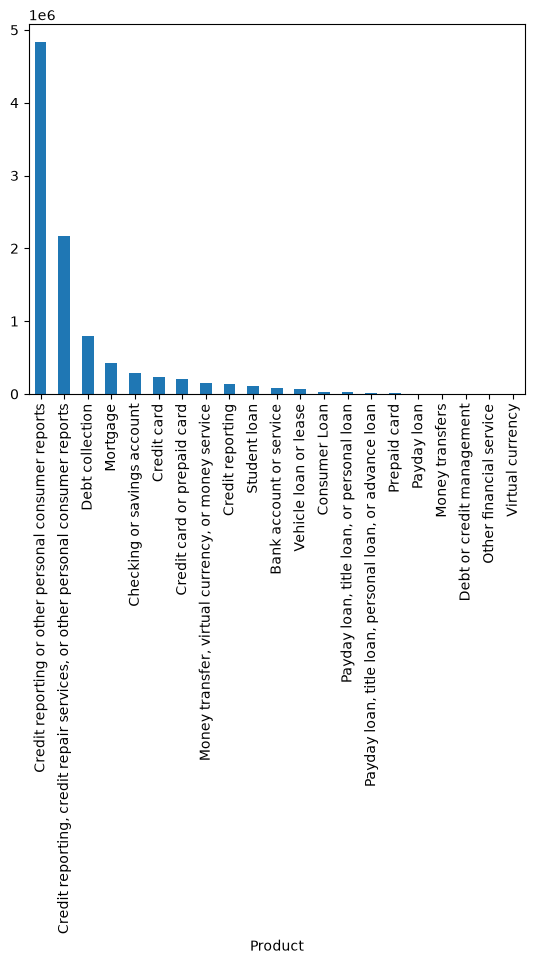

In [16]:
#Visualization
import matplotlib.pyplot as plt

df["Product"].value_counts().plot(kind="bar")
plt.show()

## Product Distribution Analysis

The distribution of complaints across financial products is highly imbalanced. The majority of complaints are concentrated in a few product categories, particularly those related to credit reporting and consumer reporting services.

### Key Findings

- **Credit reporting or other personal consumer reports** received the highest number of complaints, accounting for approximately **4.83 million records**, making it the dominant category in the dataset.
- **Credit reporting, credit repair services, or other personal consumer reports** is the second-largest category with approximately **2.16 million complaints**.
- **Debt collection** ranks third with nearly **800,000 complaints**, indicating that debt-related issues remain a significant concern for consumers.
- Traditional banking products such as **Mortgage** (422,254 complaints) and **Checking or Savings Account** (291,178 complaints) also contribute a substantial number of complaints.
- Products relevant to this project, including:
  - **Credit Card** (226,686 complaints)
  - **Checking or Savings Account** (291,178 complaints)
  - **Money Transfer, Virtual Currency, or Money Service** (145,066 complaints)
  - **Payday Loan, Title Loan, or Personal Loan** (30,641 complaints)

  represent a much smaller portion of the overall dataset compared to credit reporting categories.

### Observations

The visualization reveals a strongly right-skewed distribution where a small number of product categories account for the vast majority of complaints. This imbalance suggests that direct use of the entire dataset may cause retrieval models to be biased toward the dominant categories.

For the RAG system, the dataset will be filtered to focus only on the target financial products specified in the challenge (Credit Cards, Personal Loans, Savings Accounts, and Money Transfers). This filtering ensures that the chatbot retrieves information relevant to CrediTrust's business products and reduces noise from unrelated complaint categories such as credit reporting and debt collection.

### Implications for Modeling

- Class imbalance must be considered during sampling and preprocessing.
- Stratified sampling should be used in Task 2 to ensure fair representation of each selected product category.
- Product filtering will significantly reduce dataset size while improving retrieval relevance and response quality in the final RAG application.

3. Narrative Length Analysis

In [17]:
#Calculate word counts
df["word_count"] = df["Consumer complaint narrative"].fillna("").apply(
    lambda x: len(x.split())
)

In [18]:
#Statistics
df["word_count"].describe()

count    9.609797e+06
mean     5.446667e+01
std      1.497672e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      5.000000e+01
max      6.469000e+03
Name: word_count, dtype: float64

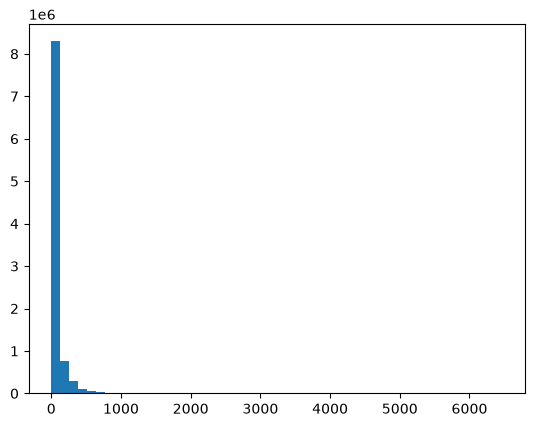

In [19]:
#Histogram
plt.hist(df["word_count"], bins=50)
plt.show()

## Narrative Length Analysis

To understand the amount of textual information available for retrieval and generation, the length of each consumer complaint narrative was calculated using word count statistics.

### Summary Statistics

| Statistic | Value |
|------------|---------:|
| Count | 9,609,797 |
| Mean | 54.47 words |
| Standard Deviation | 149.77 words |
| Minimum | 0 words |
| 25th Percentile | 0 words |
| Median (50%) | 0 words |
| 75th Percentile | 50 words |
| Maximum | 6,469 words |

### Key Findings

- The dataset contains approximately **9.6 million complaint records**.
- The **average narrative length is 54.47 words**, indicating that most complaints are relatively short.
- The **median word count is 0**, meaning that more than half of the records do not contain a consumer narrative.
- The 25th percentile is also 0, confirming that a significant portion of complaints have missing or empty narratives.
- The 75th percentile is 50 words, meaning that 75% of complaints contain 50 words or fewer.
- The longest complaint contains **6,469 words**, indicating the presence of a few extremely long narratives.

### Identifying Very Short and Very Long Complaints

#### Very Short Complaints

Very short complaints were identified as records containing few words or no narrative at all. The analysis revealed that:

- The minimum complaint length is **0 words**.
- Both the **25th percentile** and **median** are **0 words**.
- This indicates that at least **50% of the complaints contain empty or missing narratives**.
- Many remaining complaints contain only brief descriptions with limited contextual information.

These records provide little value for semantic retrieval and may negatively affect embedding quality if retained.

#### Very Long Complaints

Very long complaints were identified as narratives that are substantially longer than the average complaint length.

- The maximum complaint length is **6,469 words**.
- The standard deviation (**149.77 words**) is nearly three times larger than the mean (**54.47 words**), suggesting the presence of significant outliers.
- The histogram shows a small number of complaints extending beyond **1,000 words**, with some reaching over **6,000 words**.

These lengthy narratives often contain detailed explanations, timelines, and supporting information. While they provide rich context, embedding them as a single document may reduce retrieval effectiveness and exceed model input limits.

### Histogram Interpretation

The histogram shows a highly **right-skewed distribution** of complaint lengths.

- Most complaints are concentrated near the lower end of the distribution.
- A large number of records contain very short narratives or no narrative at all.
- Only a small number of complaints contain lengthy descriptions.
- Several extreme outliers extend beyond 1,000 words, with some reaching more than 6,000 words.

This pattern is typical of customer complaint datasets, where many users provide brief descriptions while a small number submit detailed accounts of their experiences.

### Implications for the RAG System

The analysis highlights two important preprocessing requirements:

1. **Remove complaints with empty narratives**, since they provide no useful information for semantic search or answer generation.
2. **Apply text chunking to long narratives**, as embedding entire complaints with thousands of words may reduce retrieval effectiveness and exceed model input limitations.
3. **Normalize complaint lengths through chunking**, ensuring that both short and long narratives can be represented effectively in the vector database.
4. **Focus on narrative-rich records**, as these contain the contextual information required for accurate retrieval and generation.

These findings justify the filtering and chunking steps performed in subsequent stages of the project.

4. Missing Narrative Analysis

In [20]:
df["Consumer complaint narrative"].isna().sum()

np.int64(6629041)

In [21]:
#Percentage
(
df["Consumer complaint narrative"].isna().mean()*100
)

np.float64(68.98211273349479)

## Missing Narrative Analysis

An important aspect of the exploratory data analysis was examining the availability of consumer complaint narratives, as the RAG system relies heavily on textual descriptions for retrieval and answer generation.

### Results

| Metric | Value |
|----------|---------:|
| Total Complaint Records | 9,609,797 |
| Missing Narratives | 6,629,041 |
| Percentage Missing | 68.98% |

### Key Findings

- Out of approximately **9.61 million complaint records**, **6.63 million** do not contain a consumer complaint narrative.
- Approximately **68.98%** of all complaints have missing narrative text.
- Consequently, only about **31.02%** of complaints contain usable textual descriptions that can be leveraged for semantic search and retrieval.

### Interpretation

The high percentage of missing narratives indicates that a substantial portion of CFPB complaints contain only structured metadata such as product category, issue type, company information, and submission details, without any free-text explanation from the consumer.

This finding is consistent with the narrative length analysis, where both the 25th percentile and median complaint length were zero words. Together, these results confirm that more than half of the dataset lacks meaningful textual content.

### Implications for the RAG System

The Retrieval-Augmented Generation (RAG) pipeline depends on rich textual information to generate embeddings and retrieve relevant complaint contexts. Therefore:

1. Records with missing narratives must be removed during preprocessing.
2. Only complaints containing valid narrative text should be included in the vector database.
3. Filtering out empty narratives will significantly improve retrieval quality and reduce storage and computational costs.
4. Although this filtering step reduces the dataset size substantially, it ensures that the remaining records contain meaningful information for downstream semantic search and question-answering tasks.

### Conclusion

The analysis revealed that nearly **seven out of every ten complaints** lack a consumer narrative. As a result, removing records with missing narratives is a critical preprocessing step before performing text cleaning, chunking, embedding generation, and vector indexing.

5. Filter Required Products

In [22]:
products = [
    "Credit card",
    "Personal loan",
    "Savings account",
    "Money transfer"
]

filtered_df = df[
    df["Product"].isin(products)
]

6. Remove Empty Narratives

In [23]:
filtered_df = filtered_df[
    filtered_df["Consumer complaint narrative"].notna()
]

In [24]:
filtered_df = filtered_df[
    filtered_df["Consumer complaint narrative"].str.strip() != ""
]

7. Text Cleaning

In [26]:
import re

def clean_text(text):

    text = text.lower()

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    boilerplates = [
        "i am writing to file a complaint",
        "this complaint is regarding"
    ]

    for phrase in boilerplates:
        text = text.replace(phrase, "")

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [27]:
#Apply
filtered_df["clean_text"] = filtered_df[
    "Consumer complaint narrative"
].apply(clean_text)

In [28]:
#Save
filtered_df.to_csv(
    "../data/processed/filtered_complaints.csv",
    index=False
)